In [1]:
import emcee
import matplotlib.pyplot as plt
import pyccl as ccl
import numpy as np
import corner
from IPython.display import display, Math
import seaborn as sns
import matplotlib.colors as mcolors

print(emcee.__version__)

3.1.6


In [2]:
# Define cosmology

cosmo_universe = ccl.Cosmology(Omega_c = 0.269619, 
                          Omega_b = 0.050041,
                          h = 0.6688,
                          n_s = 0.9626,
                          A_s = 2.092e-9)

Bias_distribution_fiducial = np.array([1.562362,
                             1.732963,
                             1.913252,
                             2.100644,
                             2.293210])


In [3]:
labels = [r"$\Omega_c$", r"$f_{\phi}$", r"$10^{9}A_s$", r"$h$", r"$n_s$", r"$\omega_b$",\
         r'$b_1$', r'$b_2$', r'$b_3$', r'$b_4$', r'$b_5$']

value1 = [cosmo_universe["Omega_c"], 1.0, cosmo_universe["A_s"]*1e9, cosmo_universe["h"],\
          cosmo_universe["n_s"],cosmo_universe["Omega_b"]*cosmo_universe["h"]**2,\
         Bias_distribution_fiducial[0], Bias_distribution_fiducial[1],\
         Bias_distribution_fiducial[2],Bias_distribution_fiducial[3],\
         Bias_distribution_fiducial[4]]

lower_value1 = [0.28 - 0.06, -1.5, -1.5, 1.7, 0.61 , 0.92, 0.04, 0.8,0.8,0.8,0.8,0.8]
upper_value1 = [0.36 - 0.04, 1.5, 1.5, 2.5, 0.73,1 , 0.06, 3.0,3.0,3.0,3.0,3.0]



## GR

In [4]:
# Read the HDF5 file
filename = "/global/homes/c/carolazn/CuGal_Emu_project_mcmc/mcmc/mcmc_CubicGalileon_3x2ptonly.h5"

while True:
    try:
        reader = emcee.backends.HDFBackend(filename, read_only=True)
        break  # Exit the loop once file is read successfully
    except BlockingIOError:
        # Wait for some time before retrying
        print("File is locked, retrying...")
        time.sleep(0.1)  # Sleep for 1 second before trying again

# Check how many steps have been completed so far
n_steps_completed = reader.iteration
print(f"Number of steps completed: {n_steps_completed}")

# You can also manually access the raw chain and other properties
raw_chain = reader.get_chain(discard=220)#
print(f"Current raw chain shape: {raw_chain.shape}")

tau = reader.get_autocorr_time(tol=0)
max_tau_ratio = np.max(tau * 100 / reader.iteration)
converged = max_tau_ratio < 1
print("Current iteration: {}".format(reader.iteration))
print("Max 100 x Tau/N: {}".format(max_tau_ratio))


Number of steps completed: 2553
Current raw chain shape: (2333, 256, 11)
Current iteration: 2553
Max 100 x Tau/N: 6.509265349521659


In [5]:
"""# Get the raw chain and log-probabilities
raw_chain = reader.get_chain(flat=False)  # Unflattened chain: (steps, walkers, parameters)
log_prob = reader.get_log_prob(flat=False)  # Unflattened log-probabilities: (steps, walkers)

# Calculate burn-in index
n_burnin = 400

# Remove the burn-in
raw_chain_burnin_removed = raw_chain[n_burnin:]  # Keep steps after burn-in
log_prob_burnin_removed = log_prob[n_burnin:]  # Keep log-probabilities after burn-in

# Flatten the chains after removing burn-in
raw_chain_flat = raw_chain_burnin_removed.reshape(-1, raw_chain.shape[-1])  # (samples, parameters)
log_prob_flat = log_prob_burnin_removed.reshape(-1)  # (samples,)

# Compute the mean of each parameter
mean_params = np.mean(raw_chain_flat, axis=0)

# Find the sample with the maximum log-probability
max_likelihood_index = np.argmax(log_prob_flat)
max_likelihood_params = raw_chain_flat[max_likelihood_index]

# Print the results
print("Mean parameter values (after burn-in):")
print(mean_params)

print("Maximum likelihood parameter values (after burn-in):")
print(max_likelihood_params)
print("Maximum likelihood: ", log_prob_flat[max_likelihood_index])
"""

'# Get the raw chain and log-probabilities\nraw_chain = reader.get_chain(flat=False)  # Unflattened chain: (steps, walkers, parameters)\nlog_prob = reader.get_log_prob(flat=False)  # Unflattened log-probabilities: (steps, walkers)\n\n# Calculate burn-in index\nn_burnin = 400\n\n# Remove the burn-in\nraw_chain_burnin_removed = raw_chain[n_burnin:]  # Keep steps after burn-in\nlog_prob_burnin_removed = log_prob[n_burnin:]  # Keep log-probabilities after burn-in\n\n# Flatten the chains after removing burn-in\nraw_chain_flat = raw_chain_burnin_removed.reshape(-1, raw_chain.shape[-1])  # (samples, parameters)\nlog_prob_flat = log_prob_burnin_removed.reshape(-1)  # (samples,)\n\n# Compute the mean of each parameter\nmean_params = np.mean(raw_chain_flat, axis=0)\n\n# Find the sample with the maximum log-probability\nmax_likelihood_index = np.argmax(log_prob_flat)\nmax_likelihood_params = raw_chain_flat[max_likelihood_index]\n\n# Print the results\nprint("Mean parameter values (after burn-in):

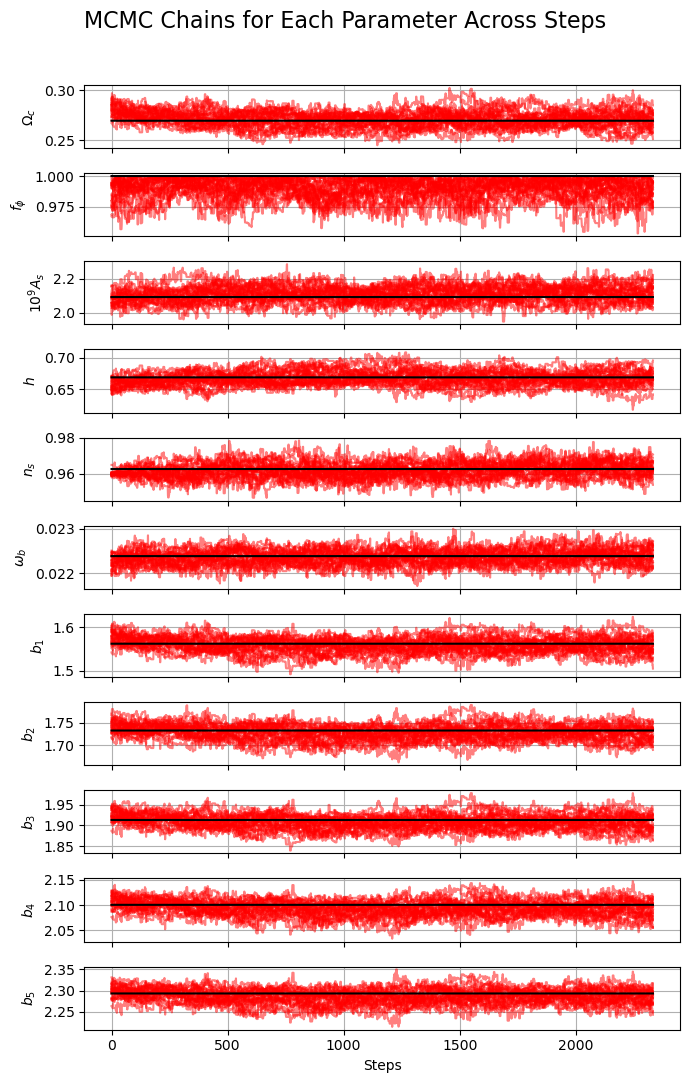

In [6]:
# Assuming `raw_chain` is the MCMC chain you have loaded from the file.
n_steps, n_walkers, n_params = raw_chain.shape

# Create a figure with subplots, one for each parameter
fig, axes = plt.subplots(n_params, figsize=(7, n_params), sharex=True)

# Iterate over each parameter and plot its evolution
for i in range(n_params):
    ax = axes[i]
    for j in range(25):
        ax.plot(raw_chain[:, j, i], alpha=0.5, color="r")  # Plot for each walker
    ax.plot(np.arange(len(raw_chain[:, 0, 0])), value1[i]*np.ones(len(raw_chain[:, 0, 0])), color="k")

    
    ax.set_ylabel(labels[i])
    ax.grid()

# Add a label for the shared x-axis (steps/iterations)
axes[-1].set_xlabel("Steps")

# Set the overall title and adjust layout
plt.suptitle("MCMC Chains for Each Parameter Across Steps", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Show the plot
#plt.savefig("chains_ESS-C_noparametrization.pdf", bbox_inches='tight')
plt.show()

In [7]:
for i in range(11):
    mcmc = np.percentile(raw_chain[:, :, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [8]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.serif": ["CMU Serif", "DejaVu Serif"]
})
col = sns.color_palette("colorblind")

In [9]:
print(col[0])  # Should output something like (r, g, b) or (r, g, b, a)


(0.00392156862745098, 0.45098039215686275, 0.6980392156862745)


(597248, 11)


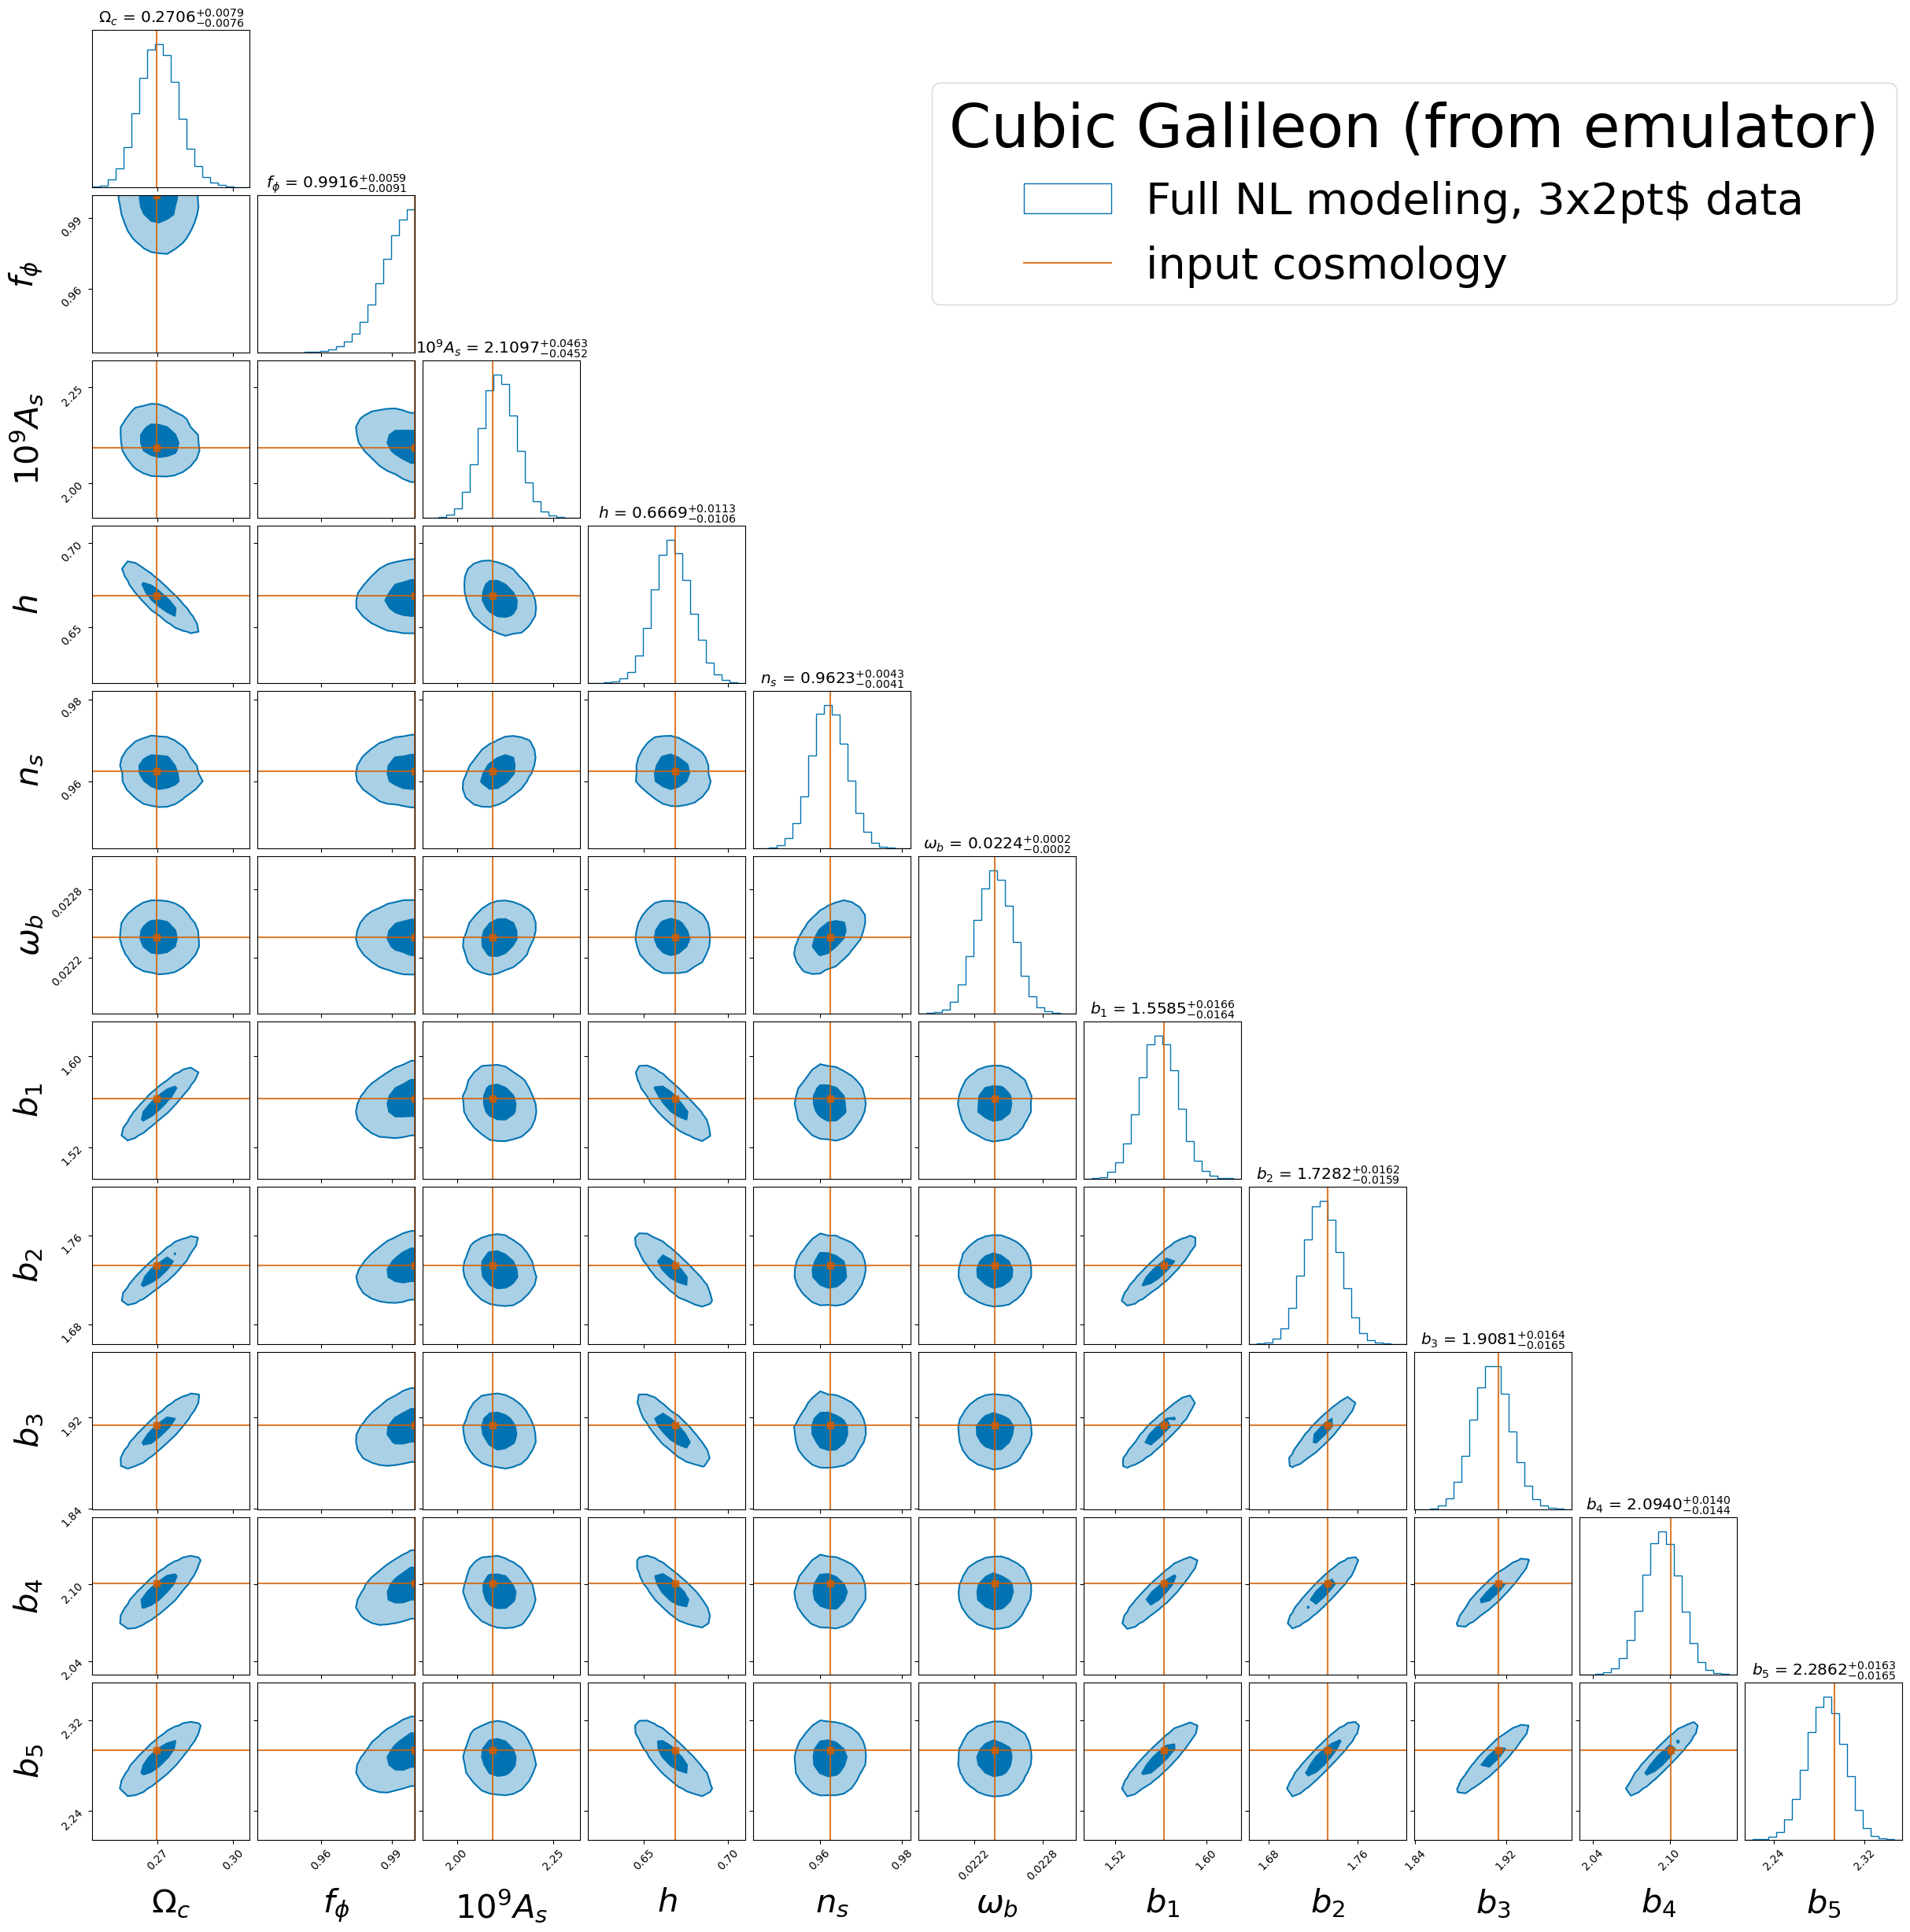

In [10]:
ndim = len(labels)

burned_chain = raw_chain
flat_samples =  burned_chain.reshape(-1, n_params)[:,:ndim]

CORNER_KWARGS = dict(
    label_kwargs=dict(fontsize=30),
    title_kwargs=dict(fontsize=14.5),
    show_titles=True,
    smooth = False,
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2)),
    plot_datapoints=False,
    fill_contours=True,
    max_n_ticks=2,
    title_fmt=".4f",
    truths=value1[:ndim],
    truth_color=mcolors.to_rgba(col[3], alpha=0.8)
)

print(flat_samples.shape)

figure = corner.corner(
    flat_samples, **CORNER_KWARGS, labels=labels, color=mcolors.to_hex(col[0]),hist_kwargs=dict(density=True)
);

######################
# Extract the axes

#plt.legend(["3x2pt, Existing method (linear scale cuts)","maximum likelihood \n (for PCA-based cuts)","3x2pt, Our method (PCA-based cuts)","input cosmology"],\
#           bbox_to_anchor=(1.0, 12.7), fontsize=40,title=r"GR universe",title_fontsize=60)
#plt.legend([r"Full NL modeling, 3x2pt$+f\sigma_8$ data","input cosmology"], bbox_to_anchor=(1.1,4.3), fontsize=20,title=r"Cubic Galileon (from emulator)",title_fontsize=25)
plt.legend([r"Full NL modeling, 3x2pt$ data","input cosmology"], bbox_to_anchor=(1.1,11.3), fontsize=40,title=r"Cubic Galileon (from emulator)",title_fontsize=55)

#plt.savefig("/global/homes/c/carolazn/CuGal_Emu_project_mcmc/Figures/3x2pt_CuGal.pdf", bbox_inches='tight')


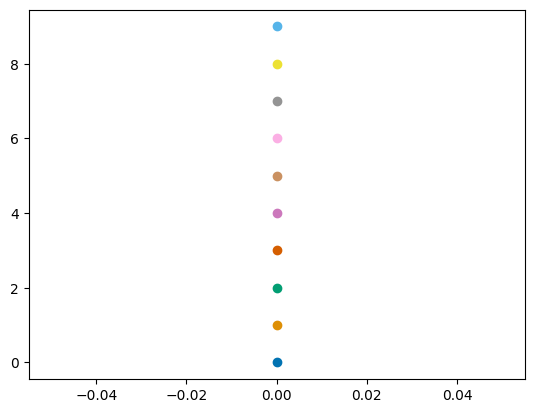

In [127]:

for i in range(10):
    plt.scatter(0,i,color=mcolors.to_hex(col[i]))